In [1]:
import torch
from matplotlib import pyplot as plt
from diffusers import DiffusionPipeline
from transformers import BitsAndBytesConfig
from diffusers.quantizers import PipelineQuantizationConfig

model_name = "Qwen/Qwen-Image"

torch_dtype = torch.bfloat16
device = "cuda"

use_bits_and_bytes = False
use_lora = False

if use_bits_and_bytes:
    # Correct quantization config for diffusers
    quantization_config = PipelineQuantizationConfig(
        quant_backend="bitsandbytes_8bit",
        quant_kwargs={
            "load_in_8bit": True,
            "llm_int8_skip_modules": ["transformer_blocks.0.img_mod"],  # Skip sensitive layers
        },
        components_to_quantize=["transformer", "text_encoder"],
    )

    pipe = DiffusionPipeline.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        torch_dtype=torch.bfloat16,
        use_safetensors=True,
    )
else:
    pipe = DiffusionPipeline.from_pretrained(
        model_name, 
        torch_dtype=torch_dtype,
        use_safetensors=True,
        load_in_8bit=True  # Simple 8-bit loading
        )

if use_lora:
    # # Load Lightning LoRA for speed
    pipe.load_lora_weights(
        "lightx2v/Qwen-Image-Lightning", 
        weight_name="Qwen-Image-Lightning-4steps-V1.0.safetensors"
    )
    true_cfg_scale=2.0
    num_inference_steps=4
else:
    true_cfg_scale=5.5
    num_inference_steps=40

# pipe = pipe.to(device)
pipe.enable_model_cpu_offload()

# Optional: Enable attention slicing for lower memory
pipe.enable_attention_slicing()

Keyword arguments {'load_in_8bit': True} are not expected by QwenImagePipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

The config attributes {'pooled_projection_dim': 768} were passed to QwenImageTransformer2DModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

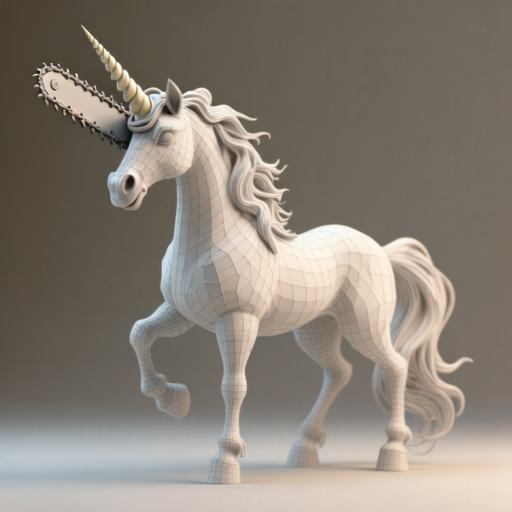

In [2]:
prompt = "A unicorn with a chainsaw instead of a horn, fantasy art, highly detailed, "
prompt_suffix = " Render of high quality 3D model on neutral background. Solid, contiguous mesh, optimized for 3D printing."
prompt = prompt + prompt_suffix
negative_prompt = "adult content, nsfw" 

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    width=512,
    height=512,
    num_inference_steps=num_inference_steps,
    true_cfg_scale=true_cfg_scale,
    generator=torch.Generator(device="cuda").manual_seed(1337)
).images[0]
image

In [3]:
def generate_quality_batch(pipe, prompts, batch_size=2):
    """
    Batch generation optimized for quality
    """
    all_images = []
    
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i+batch_size]
        
        # Pad if necessary
        original_batch_size = len(batch_prompts)
        while len(batch_prompts) < batch_size:
            batch_prompts.append(batch_prompts[-1])
        
        torch.cuda.empty_cache()
        
        with torch.no_grad():
            result = pipe(
                prompt=batch_prompts,
                width=512,
                height=512,
                num_inference_steps=num_inference_steps,
                true_cfg_scale=true_cfg_scale,
                negative_prompt=["adult content, nsfw, blurry, low quality"] * batch_size,
                generator=torch.Generator(device="cuda").manual_seed(42),
            )
            
            # Only keep the original batch size results
            all_images.extend(result.images[:original_batch_size])
    
    return all_images


  0%|          | 0/40 [00:00<?, ?it/s]

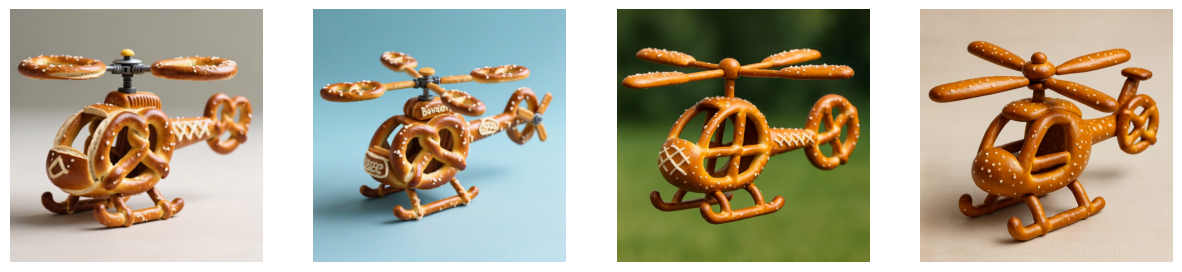

In [4]:
# Single image generation
prompt = "a pretzel copter which is a helicopter but is made out of pretzel material (bavarian brezen)"
images = generate_quality_batch(pipe, [prompt]*4, batch_size=4)

# plot all images in a grid
fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
for ax, img in zip(axs, images):
    ax.imshow(img)
    ax.axis('off')
plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

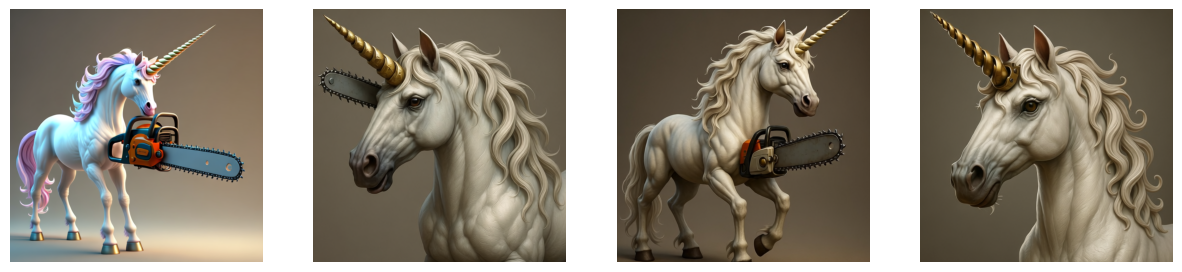

In [5]:
# Single image generation
prompt = "A unicorn with a chainsaw instead of a horn, fantasy art, highly detailed."
prompt_suffix = " Render of high quality 3D model on neutral background."
prompt = prompt + prompt_suffix
images = generate_quality_batch(pipe, [prompt]*4, batch_size=4)

# plot all images in a grid
fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
for ax, img in zip(axs, images):
    ax.imshow(img)
    ax.axis('off')
plt.show()

In [6]:
# get peak gpu memory usage
for i in range(torch.cuda.device_count()):
    peak = torch.cuda.max_memory_allocated(i) / 1024**3
    print(f"🔝 Peak GPU {i} Memory Usage: {peak:.1f}GB")

🔝 Peak GPU 0 Memory Usage: 38.4GB
🔝 Peak GPU 1 Memory Usage: 0.0GB


In [7]:
from transformers import pipeline

gemma_pipe = pipeline("text-generation", model="google/gemma-3-1b-it")
messages = [
    {"role": "user", "content": "Who are you?"},
]
gemma_pipe(messages)

Device set to use cuda:0


[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': 'Hi there! I’m Gemma, a large language model created by the Gemma team at Google DeepMind. I’m an open-weights model, which means I’m publicly available for use! \n\nI can take text and images as input and generate text as output. \n\nHow can I help you today?'}]}]

In [8]:
system_prompt = """You are a helpful assistant who creates prompts for generating rendered 3D objects. Focus on: \n 
- Avoid introductory phrases and meta-commentary, only write the prompt \n
- Add typical 3D rendering elements such as: Render, high quality 3D model, neutral background, optimized for 3D printing, ZBrush digital sculpt, stylized 3D model. \n
- Think about what the user wants and describe the desired object so that the generated image can resemble the 3D model of it. 
- Consider adding something like: safe-for-work, family-friendly if necessary"""

# system_prompt = """You are a helpful assistant who creates prompts to generate images of rendered 3D objects. Avoid introductory phrases and meta-commentary."""

def create_image_prompt(start_prompt):
    """Generate a summary for a single caption using the Gemma model"""
    # Load and process the image
    
    messages = [
                {
            "role": "system",
           "content": [{"type": "text", "text": system_prompt}]
        },
    {
        "role": "user",
        "content": [

            {"type": "text", "text":"Create a prompt based on: " + start_prompt}
        ]
    }
    ]
    return messages

  0%|          | 0/40 [00:00<?, ?it/s]

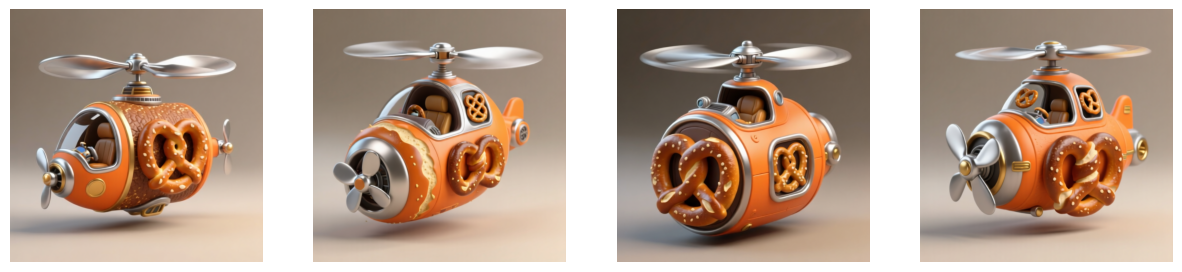

In [ ]:
prompt = "A pretzel-copter, a helicopter where the cockpit is in a pretzel shape and the whole helicopter looks like a pretzel"

enhanced_prompt_msg = create_image_prompt(prompt)
enhanced_prompt = gemma_pipe(enhanced_prompt_msg, max_new_tokens=128)[0]['generated_text'][-1]['content']
print("Enhanced prompt: ", enhanced_prompt)
images = generate_quality_batch(pipe, [enhanced_prompt]*4, batch_size=4)

# plot all images in a grid
fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
for ax, img in zip(axs, images):
    ax.imshow(img)
    ax.axis('off')
plt.show()

Enhanced prompt:  Render a highly detailed, stylized 3D model of a unicorn with a chainsaw instead of a horn, fantasy art, neutral background, optimized for 3D printing, ZBrush digital sculpt, intricate details, dynamic pose, vibrant colors, safe-for-work, family-friendly.


  0%|          | 0/40 [00:00<?, ?it/s]

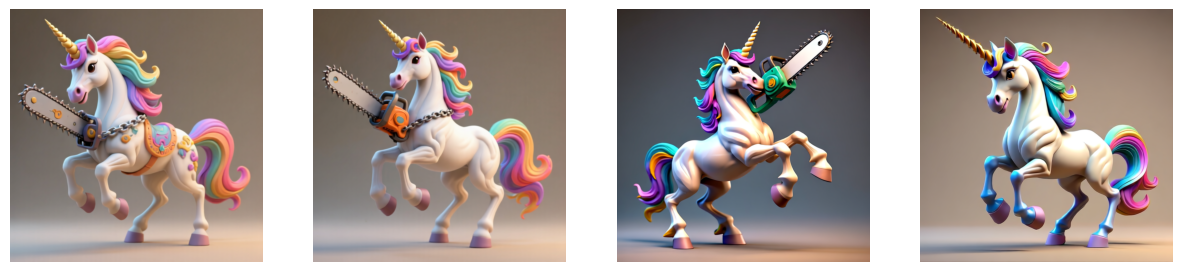

In [11]:
prompt = "A unicorn with a chainsaw instead of a horn, fantasy art, highly detailed"
enhanced_prompt_msg = create_image_prompt(prompt)
enhanced_prompt = gemma_pipe(enhanced_prompt_msg, max_new_tokens=128)[0]['generated_text'][-1]['content']
print("Enhanced prompt: ", enhanced_prompt)
images = generate_quality_batch(pipe, [enhanced_prompt]*4, batch_size=4)

# plot all images in a grid
fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
for ax, img in zip(axs, images):
    ax.imshow(img)
    ax.axis('off')
plt.show()

In [12]:
# get peak gpu memory usage
for i in range(torch.cuda.device_count()):
    peak = torch.cuda.max_memory_allocated(i) / 1024**3
    print(f"🔝 Peak GPU {i} Memory Usage: {peak:.1f}GB")

🔝 Peak GPU 0 Memory Usage: 40.4GB
🔝 Peak GPU 1 Memory Usage: 0.0GB
